## DNAscape quickstart examples

### Imports and configuration

In [1]:
# Import DNAscape
from dnascape import *

In [18]:
# DEV ONLY - Temporary updates (remove before release)
%load_ext autoreload
%autoreload 2

import sys
import importlib
from pathlib import Path

# If notebook is in examples/, add repo root
repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))

pkg = importlib.import_module("dnascape")
pkg_dir = Path(pkg.__file__).parent

# import/reload every module in dnascape/
for py in pkg_dir.glob("*.py"):
    if py.name == "__init__.py":
        continue
    mod_name = f"dnascape.{py.stem}"
    mod = importlib.import_module(mod_name)
    importlib.reload(mod)

    # export public names to notebook globals
    public = getattr(mod, "__all__", None)
    if public is None:
        public = [k for k in mod.__dict__ if not k.startswith("_")]
    for name in public:
        globals()[name] = getattr(mod, name)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
dnascape

NameError: name 'dnascape' is not defined

### Examples

In [2]:
timedata = loadcsv('example', example='replication_timing_hESC', chr_number=1)

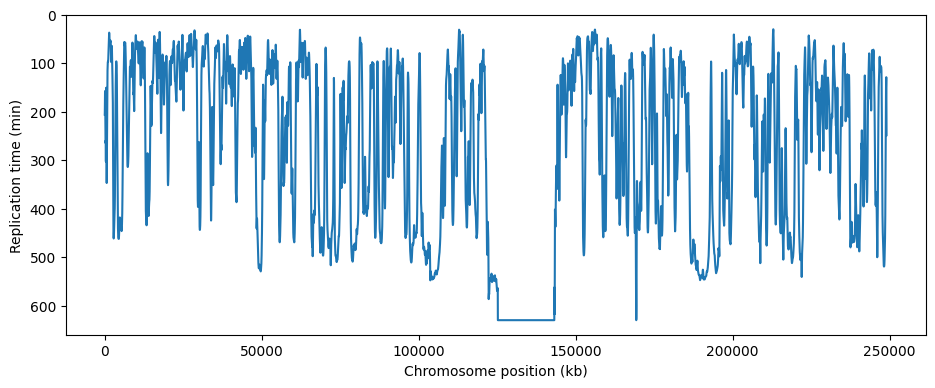

In [3]:
plotf(timedata, xtitle='Chromosome position (kb)', ytitle='Replication time (min)', invyQ=True, saveQ=True, sname='quick1', ext='png')

In [4]:
frates = rfit('replication_timing', 'firing_rate', source=timedata, maxiter=2)

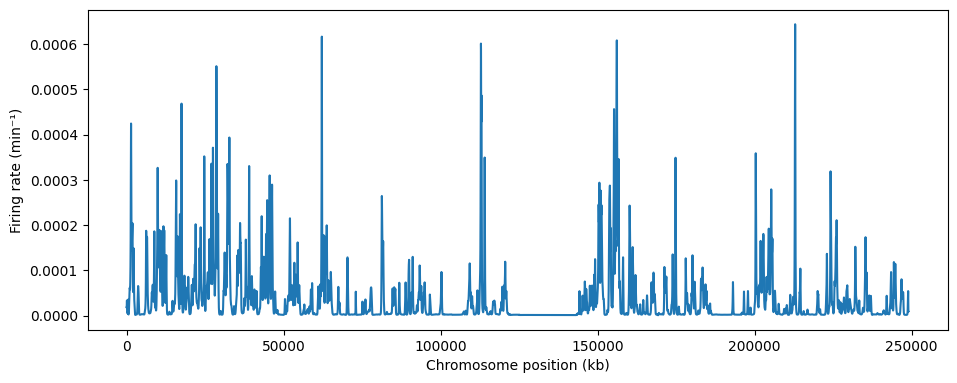

In [5]:
plotf(frates, xtitle='Chromosome position (kb)', ytitle='Firing rate (min⁻¹)')

In [6]:
simres = rsim(frates, time_statsQ=True, sim_number=100)

In [7]:
timesim = simres['replication_timing']
iod = simres['inter_origin_distances']
frep = simres['replicated_fraction']
forka = simres['active_forks']
nroris = simres['num_oris']
effic = simres['efficiency']

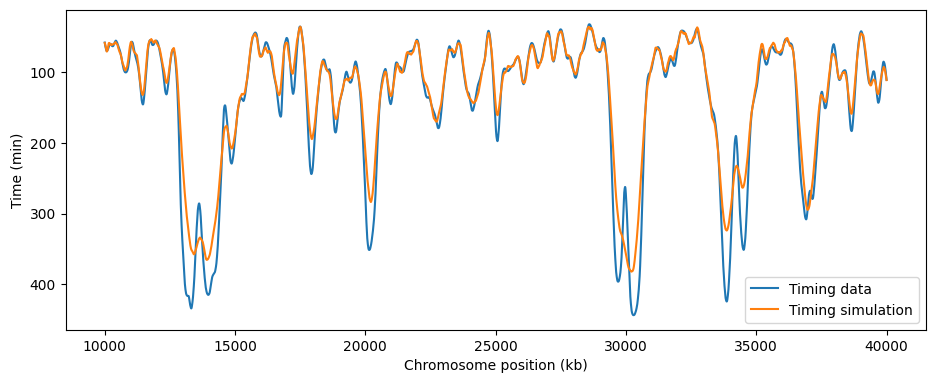

In [8]:
region = range(10000,40000)
plotf(timedata[region], timesim[region], x_array=region,
      labels=['Timing data', 'Timing simulation'], xtitle='Chromosome position (kb)', ytitle='Time (min)', invyQ=True)

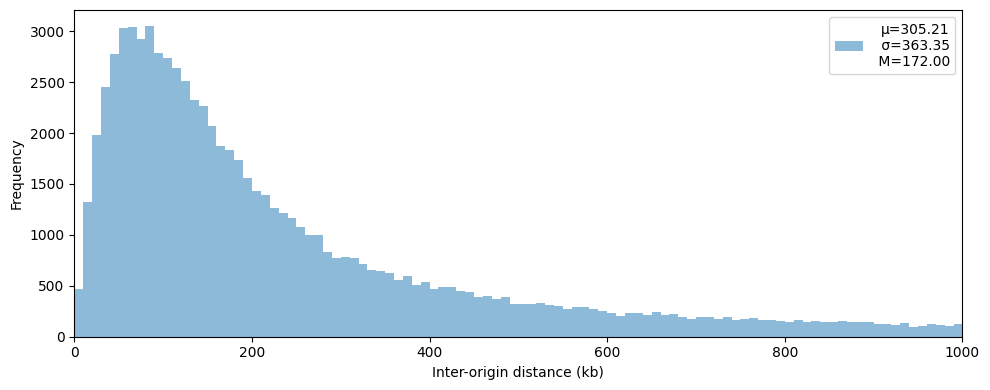

In [9]:
ploth(iod, xtitle='Inter-origin distance (kb)', bin_size=10, xmax=1000)

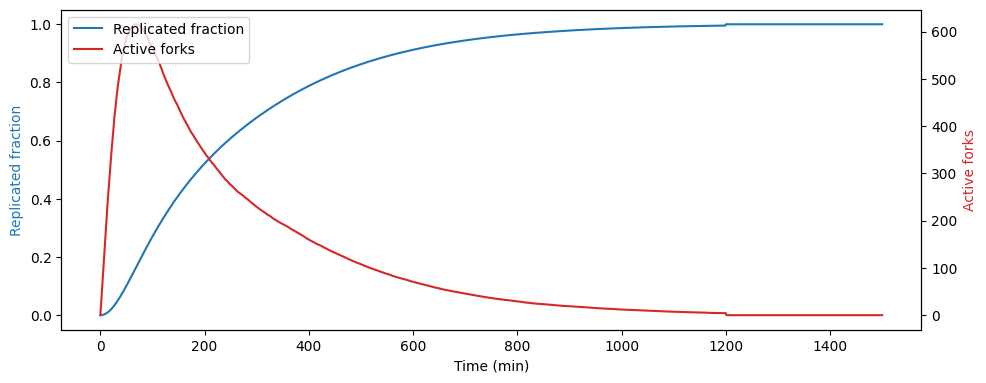

In [16]:
plotf(frep, forka, xtitle='Time (min)', labels=['Replicated fraction','Active forks'], dual_axis=True)

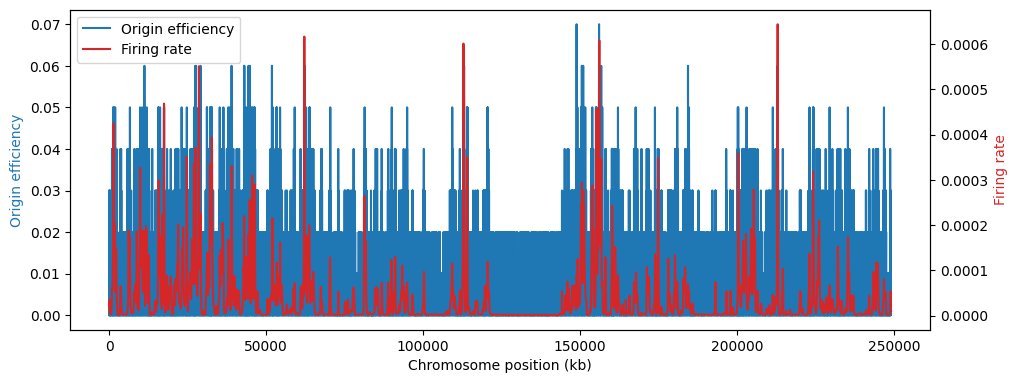

In [17]:
plotf(effic, frates, xtitle='Chromosome position (kb)', labels=['Origin efficiency','Firing rate'], dual_axis=True)

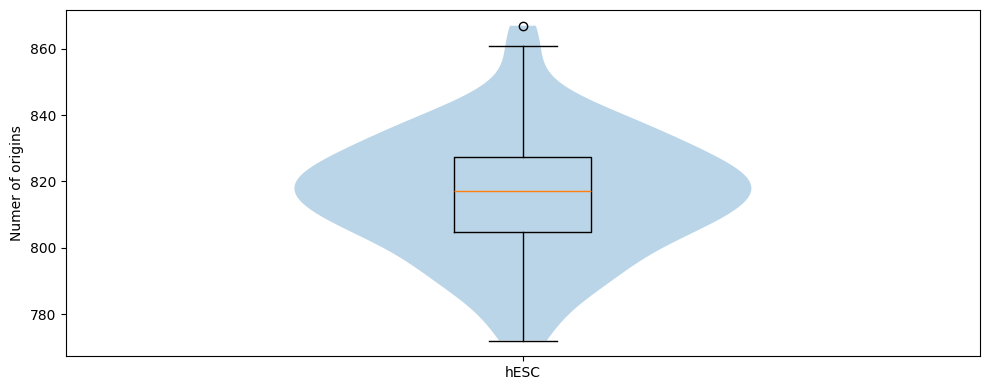

In [13]:
plotw(nroris, ytitle='Number of origins', labels=['hESC'], violinQ=True)

In [14]:
nroris_dict = {}
for chr_number in range(1,23):
    fratesdata = loadcsv('example', example='firing_rate_hESC', chr_number=chr_number)
    simres = rsim(fratesdata, time_statsQ=True, sim_number=100)
    nroris_dict[chr_number] = simres['num_oris']

KeyboardInterrupt: 

In [ ]:
plotw(*nroris_dict.values(), xtitle='Chromosome', ytitle='Number of origins in hESC', labels=[f'{nr}' for nr in range(1,23)], violinQ=True)

### Neater examples

In [ ]:
timedata = loadcsv('example', example='replication_timing_Pl', chr_number=1)
timedata = rescale(timedata, [0, 60])
frates = rfit('replication_timing', 'firing_rate', source=timedata, fork_speed=0.6, maxiter=10, resolution=5, perQ=True, stall_rate=0., save_errQ=True)

In [ ]:
simres = rsim(frates, time_statsQ=True, fork_speed=0.6, sim_number=1, perQ=True, stall_rate=0.1)
timesim = simres['replication_timing']

In [ ]:
effic = simres['efficiency']

In [ ]:
plotf(timesim, invyQ=True, resolution=5)

In [ ]:
mplotf([timesim, [timesim,frates], [timesim,frates], effic], 
       figsize=(10,2), mregion_high=[range(1,60),range(80,100), range(800,900)], mxtitle='Chromosome position',
       mlabels=[None,['ds','ds2'], ['ds','ds2'],['Firing rate']], mdual_axis=[False, True,False,False])

In [ ]:
# ---- Example usage ----
gtf_path = "data/other/gencode/gencode.v49.annotation.gtf.gz"
chrom = "chr1"
start = 10_000_000
end   = 11_000_000

genes = load_gene_models_from_gtf_gz(
    gtf_path, chrom, start, end,
    keep_gene_types="protein_coding",  # e.g. {"protein_coding"} if you want
    max_genes=20
)

ax = plot_gene_track(genes, chrom, start, end, show_direction=True, show_names=True, denseQ=True)
plt.tight_layout()
plt.show()

In [ ]:
region = range(10000,11000)
mplotf([timedata[region]], mx_array=[[region]], 
       figsize=(10,2), mxtitle='Chromosome position', showgeneQ=True)

In [ ]:
mplotf([timedata[10000:11000]],
       figsize=(10,2), mxtitle='Chromosome position', showgeneQ=False)

In [ ]:
simres = rsim(frates, time_statsQ=True, sim_number=1)

In [ ]:
timesim = simres['replication_timing']
iod = simres['inter_ori_distances']
frep = simres['fraction_replicated']
forka = simres['active_forks']
nroris = simres['num_oris']
effic = simres['efficiency']
rfd = simres['fork_directionality']

In [ ]:
simres.keys()

In [ ]:
region = range(10000,15001)
mplotf([timesim[region], rfd[region]], minvyQ=[True], mx_array=[[region], [region]])